In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.6
plt.rcParams["grid.linestyle"] = "--"

In [13]:
us = pd.read_csv(
    "/Users/OA/US_Accidents_March23.csv",
    usecols=[
        "Severity",
        "State",
        "City",
        "Start_Time",
        "Weather_Condition",
        "Sunrise_Sunset"
    ]
)

us = us.sample(200000, random_state=42)

print(us.shape)

(200000, 6)


The following charts use a random sample of 200,000 U.S. accident records for descriptive comparison.

In [15]:
us["HighSeverity"] = (us["Severity"] >= 3).astype(int)

us["Rain"] = us["Weather_Condition"].fillna("").str.contains(
    "Rain", case=False
).astype(int)

us["Night"] = (us["Sunrise_Sunset"] == "Night").astype(int)

us["Start_Time"] = pd.to_datetime(
    us["Start_Time"],
    errors="coerce",
    format="mixed"
)

us["Month"] = us["Start_Time"].dt.month

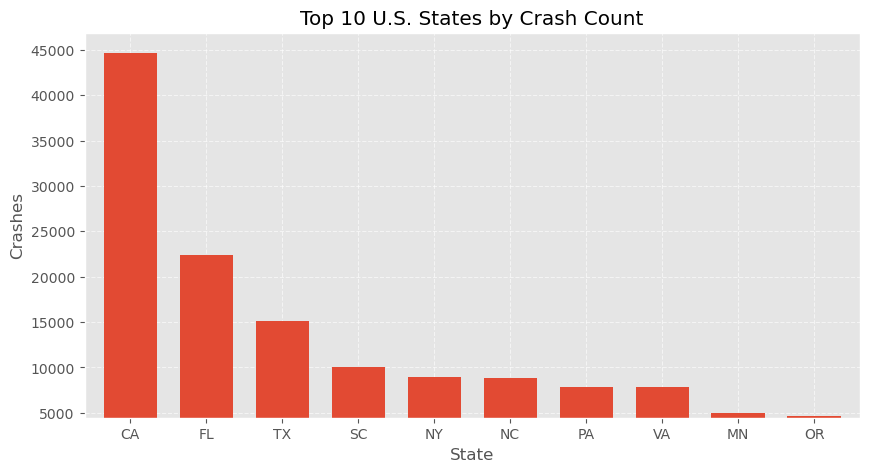

In [17]:
top_states = us["State"].value_counts().head(10)

top_states.plot(kind="bar", width=0.7)

plt.title("Top 10 U.S. States by Crash Count")
plt.xlabel("State")
plt.ylabel("Crashes")
plt.xticks(rotation=0)
plt.ylim(top_states.min()*0.95, top_states.max()*1.05)

plt.show()

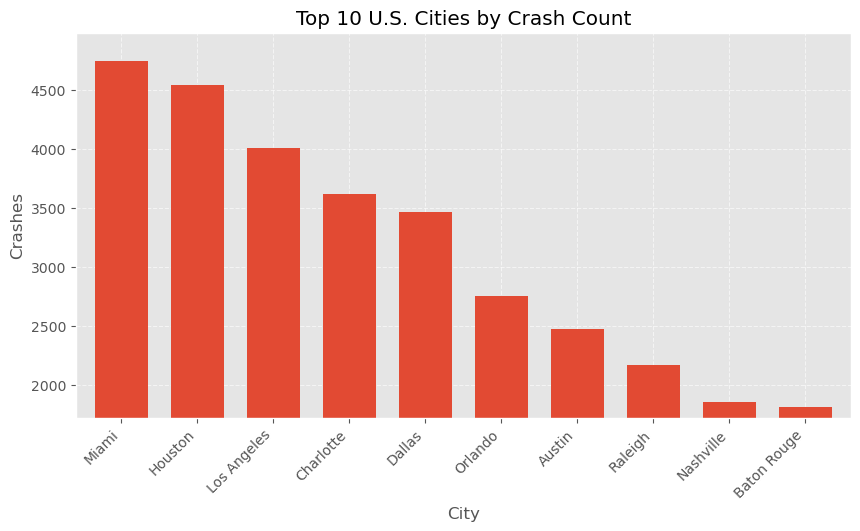

In [21]:
top_cities = us["City"].value_counts().head(10)

top_cities.plot(kind="bar", width=0.7)

plt.title("Top 10 U.S. Cities by Crash Count")
plt.xlabel("City")
plt.ylabel("Crashes")
plt.xticks(rotation=45, ha="right")
plt.ylim(top_cities.min()*0.95, top_cities.max()*1.05)

plt.show()

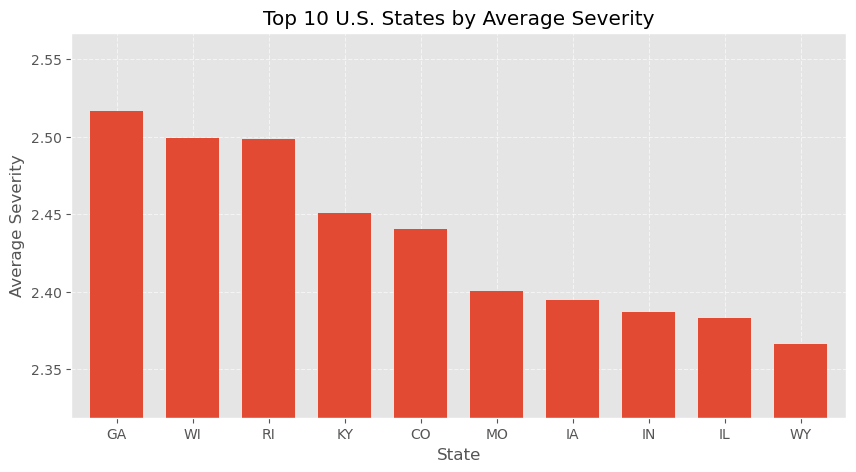

In [23]:
state_avg = us.groupby("State")["Severity"].mean()

top_severity_states = state_avg.sort_values(ascending=False).head(10)

top_severity_states.plot(kind="bar", width=0.7)

plt.title("Top 10 U.S. States by Average Severity")
plt.xlabel("State")
plt.ylabel("Average Severity")
plt.xticks(rotation=0)
plt.ylim(top_severity_states.min()*0.98, top_severity_states.max()*1.02)

plt.show()

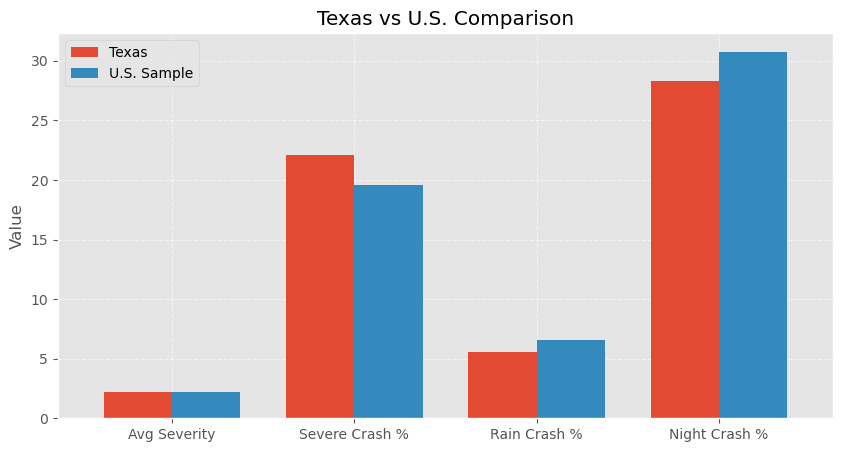

In [25]:
tx = us[us["State"] == "TX"]

comparison = pd.DataFrame({
    "Texas": [
        tx["Severity"].mean(),
        tx["HighSeverity"].mean()*100,
        tx["Rain"].mean()*100,
        tx["Night"].mean()*100
    ],
    "U.S. Sample": [
        us["Severity"].mean(),
        us["HighSeverity"].mean()*100,
        us["Rain"].mean()*100,
        us["Night"].mean()*100
    ]
},
index=[
    "Avg Severity",
    "Severe Crash %",
    "Rain Crash %",
    "Night Crash %"
])

comparison.plot(kind="bar", width=0.75)

plt.title("Texas vs U.S. Comparison")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.legend(loc="best")

plt.show()

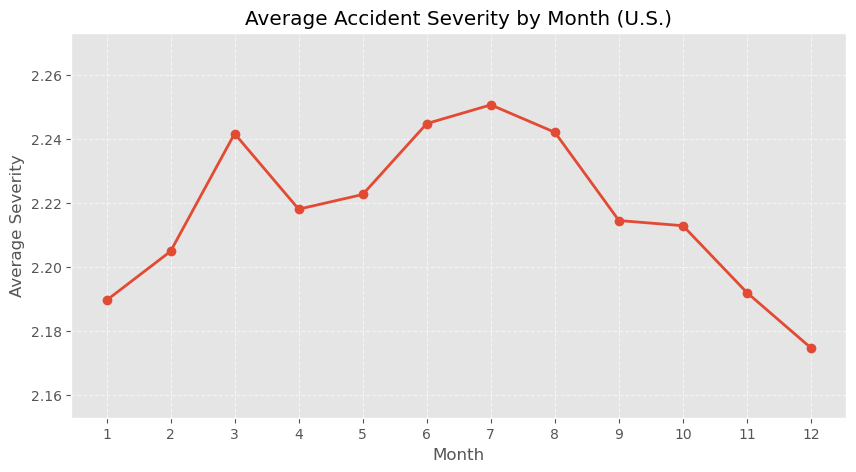

In [27]:
month_avg = us.groupby("Month")["Severity"].mean()

month_avg.plot(kind="line", marker="o", linewidth=2)

plt.title("Average Accident Severity by Month (U.S.)")
plt.xlabel("Month")
plt.ylabel("Average Severity")
plt.xticks(range(1,13))
plt.ylim(month_avg.min()*0.99, month_avg.max()*1.01)

plt.show()